<a href="https://colab.research.google.com/github/vbrasila/agentes-2026-2-equipe/blob/main/exemplar_service_desk_Thiago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exemplar do professor — Service Desk

**Tópicos Especiais em IA · Agentes Inteligentes · IFES Serra · 2026/2**

> **O problema em uma frase.** Hoje, o analista do service desk precisa
> descobrir a causa de um chamado escrito em texto livre, mas o dado que decide
> está espalhado por seis consultas diferentes, o que faz o chamado ser fechado
> sem causa ou escalado sem necessidade.

**O que este notebook mostra, e é uma coisa só:** em três dos cinco chamados o
procedimento fixo basta e é mais barato. Em dois, ele não basta. Saber em qual
dos dois grupos o seu problema cai é a decisão de projeto do Marco 1.

*ERP é Enterprise Resource Planning.

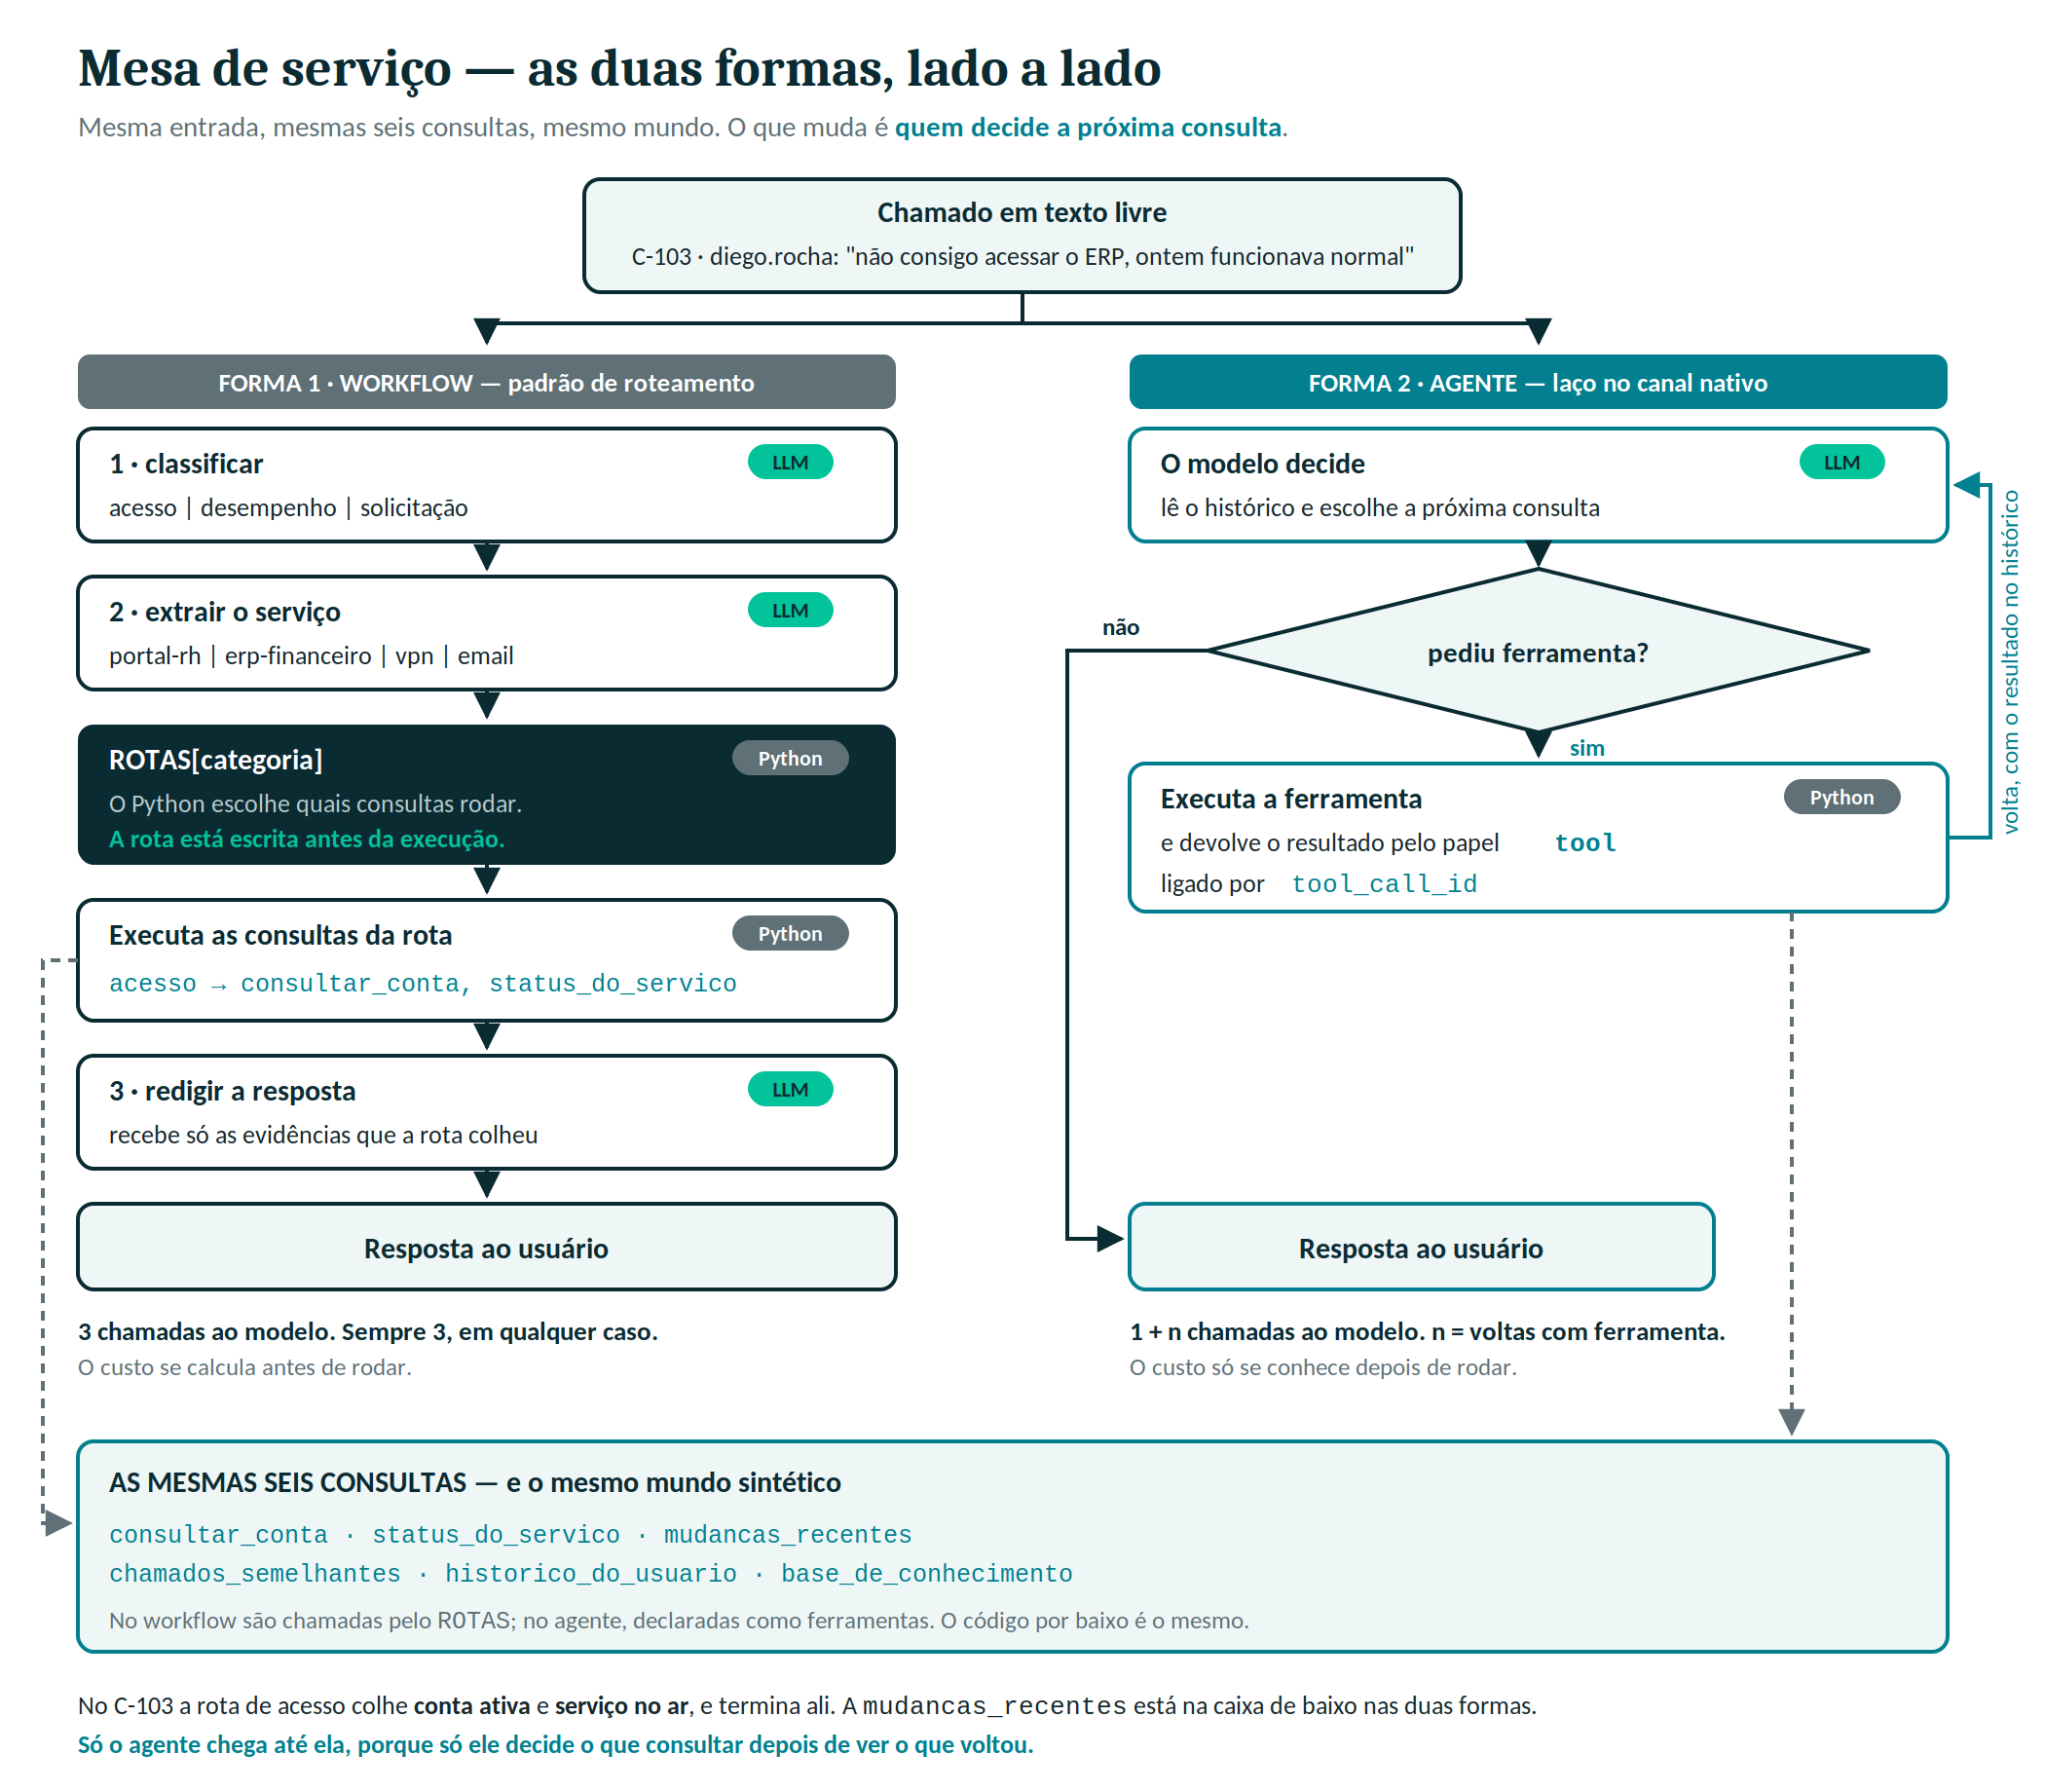

## Parte 0 — Preparo

Célula de instalação com versão fixada e chave pelos *Secrets* do Colab, como
em todos os encontros desde o 2. Nada de `.env`, nada de chave em arquivo.

In [19]:
# ---------------------------------------------------------------------
# PREPARO. Versoes fixadas: a VM do Colab e apagada entre sessoes e o
# notebook precisa se reconstruir sozinho.
# ---------------------------------------------------------------------
%pip install -q "openai==1.109.1"

In [20]:
import os, time, json, types, unicodedata
from openai import OpenAI


def obter_chave(nome: str) -> str:
    """Le um segredo dos Secrets do Colab; fora do Colab, da variavel de ambiente."""
    try:
        from google.colab import userdata
        return userdata.get(nome)
    except ImportError:
        valor = os.getenv(nome)
        if not valor:
            raise RuntimeError(f"Defina {nome} nos Secrets do Colab ou no ambiente.")
        return valor


LLM_BASE_URL = "https://api.groq.com/openai/v1"
LLM_API_KEY = obter_chave("GROQ_API_KEY")
LLM_MODEL = "openai/gpt-oss-20b"

# Preco publicado em console.groq.com/pricing, conferido em 21/08/2026.
# Dolares por MILHAO de tokens.
PRECOS = {
    "openai/gpt-oss-20b":  {"entrada": 0.075, "saida": 0.30},
    "openai/gpt-oss-120b": {"entrada": 0.150, "saida": 0.60},
}
TPM = 8_000

cliente = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)
print("chave carregada, termina em:", LLM_API_KEY[-4:])
print("modelo:", LLM_MODEL)
print(f"TPM do plano gratuito: {TPM:,}")

chave carregada, termina em: TE3R
modelo: openai/gpt-oss-20b
TPM do plano gratuito: 8,000


In [21]:
def _espera_sugerida(erro, padrao: float) -> float:
    """Le o cabecalho retry-after, se o provedor mandou. Senao usa o padrao."""
    try:
        cab = getattr(getattr(erro, "response", None), "headers", {}) or {}
        v = cab.get("retry-after") or cab.get("Retry-After")
        if v:
            return float(v)
    except (TypeError, ValueError):
        pass
    return padrao


def chamar(mensagens, temperatura: float = 0.0, tentativas: int = 5,
           max_tokens: int = 1200, **extra):
    """Chama o modelo tolerando 429/503, com espera crescente.

    NAO troca de modelo depois de N falhas. O modelo tem de ser constante:
    a variavel deste notebook e a FORMA -- workflow ou agente.
    """
    espera = 2.0
    for t in range(tentativas):
        try:
            r = cliente.chat.completions.create(
                model=LLM_MODEL, messages=mensagens,
                temperature=temperatura, max_tokens=max_tokens, **extra)
            if r.choices[0].finish_reason == "length":
                print("  [AVISO: resposta CORTADA por max_tokens.]")
            return r
        except Exception as e:
            codigo = getattr(e, "status_code", None)
            if codigo not in (429, 500, 502, 503, 504) or t == tentativas - 1:
                raise
            pausa = _espera_sugerida(e, espera)
            print(f"  [{codigo}] esperando {pausa:.0f}s  (nao invalida a medicao)")
            time.sleep(pausa)
            espera *= 2
    raise RuntimeError("todas as tentativas falharam")


def custo_usd(entrada: int, saida: int, modelo: str = None) -> float:
    """Custo em dolares, pelo preco publicado do Groq."""
    p = PRECOS[modelo or LLM_MODEL]
    return (entrada * p["entrada"] + saida * p["saida"]) / 1_000_000


print("chamada e calculo de custo prontos.")

chamada e calculo de custo prontos.


## Parte 1 — O mundo

Cinco usuários, quatro serviços, um registro de mudanças, os chamados abertos
agora, o histórico de cada usuário e quatro artigos de procedimento.

**Tudo sintético.** Nenhum dado de pessoa real, nenhum sistema real. Existe **verdade de terra** para dizer que uma resposta acertou.

In [22]:
# ---------------------------------------------------------------------
# O MUNDO. Tudo sintetico, tudo inventado, nenhum dado de pessoa real.
# A empresa chama-se Vertice. Sete usuarios, quatro servicos.
# ---------------------------------------------------------------------

CONTAS = {
    "ana.souza":      {"status": "bloqueada",
                       "motivo": "5 tentativas de senha erradas em -19h",
                       "grupos": ["rh_leitura"],
                       "troca_senha": "-38 dias"},
    "bruno.lima":     {"status": "ativa", "motivo": "",
                       "grupos": ["erp_leitura", "erp_lancamento"],
                       "troca_senha": "-12 dias"},
    "carla.dias":     {"status": "ativa", "motivo": "",
                       "grupos": ["rh_leitura", "vpn_externa"],
                       "troca_senha": "-3 dias"},
    "diego.rocha":    {"status": "ativa", "motivo": "",
                       "grupos": ["rh_leitura"],
                       "troca_senha": "-20 dias"},
    "fernando.alves": {"status": "ativa", "motivo": "",
                       "grupos": ["rh_leitura"],
                       "troca_senha": "-88 dias"},
    "elena.matos":    {"status": "ativa", "motivo": "",
                       "grupos": ["rh_leitura"],
                       "troca_senha": "-17 dias"},
    "joao.prado":     {"status": "ativa", "motivo": "",
                       "grupos": ["rh_leitura"],
                       "troca_senha": "-5 dias"},
}

SERVICOS = {
    "portal-rh":      {"estado": "no ar", "desde": "-30 dias", "nota": ""},
    "erp-financeiro": {"estado": "no ar", "desde": "-9 dias",
                       "nota": "lentidao relatada por alguns usuarios hoje de manha"},
    "vpn":            {"estado": "em manutencao", "desde": "-1h",
                       "nota": "janela programada, previsao de retorno em +30min"},
    "email":          {"estado": "no ar", "desde": "-30 dias", "nota": ""},
}

MUDANCAS = {
    "erp-financeiro": [("-6h", "revisao de perfis de acesso: o grupo erp_leitura "
                               "foi removido de 12 usuarios"),
                       ("-31h", "atualizacao de indice do banco de dados")],
    "portal-rh":      [],
    "vpn":            [("-1h", "inicio de janela de manutencao programada")],
    "email":          [],
}

CHAMADOS_ABERTOS = {
    "erp-financeiro": ["C-103 diego.rocha: nao consegue acessar",
                       "C-106 elena.matos: nao consegue acessar",
                       "C-108 joao.prado: nao consegue acessar",
                       "C-102 bruno.lima: lentidao ao abrir telas"],
    "portal-rh":      ["C-101 ana.souza: usuario ou senha invalidos"],
    "vpn":            ["C-104 carla.dias: tudo travando"],
    "email":          [],
}

HISTORICO = {
    "ana.souza":      ["-60 dias portal-rh: esqueci a senha",
                       "-120 dias portal-rh: erro ao emitir holerite"],
    "bruno.lima":     ["-14 dias erp-financeiro: relatorio nao fecha",
                       "-45 dias erp-financeiro: exportacao lenta"],
    "carla.dias":     ["-4 dias vpn: cai sozinha depois de 20 min",
                       "-11 dias vpn: nao conecta de casa",
                       "-26 dias vpn: pede certificado toda vez"],
    "diego.rocha":    ["-70 dias erp-financeiro: duvida de lancamento"],
    "fernando.alves": ["-200 dias portal-rh: primeiro acesso"],
    "elena.matos":    ["-90 dias erp-financeiro: acesso ao modulo de compras"],
    "joao.prado":     ["-35 dias erp-financeiro: relatorio em branco"],
}

BASE_CONHECIMENTO = {
    "senha": ("KB-014: campanha de troca de senha. Entre -3 e +4 dias o TI envia "
              "aviso de expiracao pelo endereco ti@vertice.exemplo. O aviso e "
              "LEGITIMO e pede troca pelo portal, nunca por link no email."),
    "bloqueio": ("KB-002: a conta bloqueia apos 5 tentativas erradas. O desbloqueio "
                 "e feito pelo autoatendimento, sem abrir chamado. A senha vale 90 "
                 "dias a contar da ultima troca."),
    "vpn": ("KB-007: janelas de manutencao da VPN ocorrem as quartas, das 6h as 7h, "
            "e sao avisadas por email na vespera."),
    "perfil": ("KB-021: perda de acesso apos revisao de perfis. Se o usuario perdeu "
               "um grupo numa revisao, a devolucao e pedida ao gestor da area."),
}

In [23]:
# ---------------------------------------------------------------------
# AS SEIS CONSULTAS. Sao funcoes Python comuns; viram ferramentas depois.
# Todas devolvem TEXTO, e nenhuma levanta excecao.
# ---------------------------------------------------------------------

CHAMADO_ATUAL = ""   # id do chamado em atendimento; a ferramenta se exclui da lista

def consultar_conta(usuario: str) -> str:
    """Devolve o estado da conta de um usuario: ativa ou bloqueada, os grupos
    de acesso que ela tem, e ha quanto tempo a senha foi trocada."""
    c = CONTAS.get(usuario)
    if not c:
        return f"ERRO: usuario {usuario} nao consta do diretorio"
    extra = f"; motivo: {c['motivo']}" if c["motivo"] else ""
    return (f"{usuario}: conta {c['status']}{extra}; grupos {', '.join(c['grupos'])}; "
            f"senha trocada {c['troca_senha']}")


def status_do_servico(servico: str) -> str:
    """Devolve o estado atual de um servico corporativo e desde quando ele
    esta nesse estado."""
    s = SERVICOS.get(servico)
    if not s:
        return f"ERRO: servico {servico} nao consta do catalogo"
    nota = f" -- {s['nota']}" if s["nota"] else ""
    return f"{servico}: {s['estado']} desde {s['desde']}{nota}"


def mudancas_recentes(servico: str, horas: str = "24") -> str:
    """Lista as mudancas aplicadas a um servico nas ultimas N horas."""
    if servico not in MUDANCAS:
        return f"ERRO: servico {servico} nao consta do catalogo"
    try:
        janela = int(float(horas))
    except (TypeError, ValueError):
        return "ERRO: horas deve ser um numero, por exemplo 24"
    dentro = [f"{q} {d}" for q, d in MUDANCAS[servico]
              if int(q.strip("-h")) <= janela]
    if not dentro:
        return f"{servico}: 0 mudancas nas ultimas {janela}h"
    return (f"{servico}: {len(dentro)} mudanca(s) nas ultimas {janela}h -- "
            + "; ".join(dentro))


def chamados_semelhantes(servico: str) -> str:
    """Lista os OUTROS chamados abertos AGORA sobre o mesmo servico, sem contar o "
       "chamado em atendimento. Serve para saber se o problema atinge um usuario so "
       "ou varios."""
    if servico not in CHAMADOS_ABERTOS:
        return f"ERRO: servico {servico} nao consta do catalogo"
    lista = [c for c in CHAMADOS_ABERTOS[servico]
             if not (CHAMADO_ATUAL and c.startswith(CHAMADO_ATUAL))]
    if not lista:
        return f"{servico}: nenhum OUTRO chamado aberto no momento"
    return (f"{servico}: {len(lista)} outro(s) chamado(s) aberto(s) -- "
            + "; ".join(lista))


def historico_do_usuario(usuario: str) -> str:
    """Lista os chamados anteriores de um usuario, com o servico de cada um.
    Serve para descobrir com que servicos esse usuario costuma ter problema."""
    h = HISTORICO.get(usuario)
    if h is None:
        return f"ERRO: usuario {usuario} nao consta do diretorio"
    if not h:
        return f"{usuario}: nenhum chamado anterior"
    return f"{usuario}: {len(h)} chamado(s) anterior(es) -- " + "; ".join(h)


def base_de_conhecimento(termo: str) -> str:
    """Busca um artigo da base de conhecimento por assunto. Assuntos validos:
    senha, bloqueio, vpn, perfil."""
    t = (termo or "").strip().lower()
    for chave, texto in BASE_CONHECIMENTO.items():
        if chave in t or t in chave:
            return texto
    return (f"nenhum artigo para '{termo}'. Assuntos disponiveis: "
            + ", ".join(BASE_CONHECIMENTO))


print("o mundo da Vertice esta montado.")
print(" ", consultar_conta("ana.souza"))
print(" ", status_do_servico("erp-financeiro"))
print(" ", mudancas_recentes("erp-financeiro", "24"))

o mundo da Vertice esta montado.
  ana.souza: conta bloqueada; motivo: 5 tentativas de senha erradas em -19h; grupos rh_leitura; senha trocada -38 dias
  erp-financeiro: no ar desde -9 dias -- lentidao relatada por alguns usuarios hoje de manha
  erp-financeiro: 1 mudanca(s) nas ultimas 24h -- -6h revisao de perfis de acesso: o grupo erp_leitura foi removido de 12 usuarios


In [24]:
# --- AUTOTESTE DO MUNDO. Nenhuma chamada de rede. -------------------
assert "bloqueada" in consultar_conta("ana.souza")
assert "ativa" in consultar_conta("diego.rocha")
assert "erp_leitura" not in consultar_conta("diego.rocha")   # ele PERDEU o grupo
assert "erp_leitura" in consultar_conta("bruno.lima")        # e o bruno nao
assert "no ar" in status_do_servico("erp-financeiro")
assert "manutencao" in status_do_servico("vpn")
assert "revisao de perfis" in mudancas_recentes("erp-financeiro", "24")
assert "0 mudancas" in mudancas_recentes("portal-rh", "24")
assert "3 chamado" in historico_do_usuario("carla.dias")
assert "vpn" in historico_do_usuario("carla.dias")
assert "KB-014" in base_de_conhecimento("senha")
assert consultar_conta("ninguem").startswith("ERRO")

print("mundo conferido: 12 asercoes passaram.")
print()
print("A linha que decide o exemplar:")
print(" ", consultar_conta("diego.rocha"))
print(" ", status_do_servico("erp-financeiro"))

mundo conferido: 12 asercoes passaram.

A linha que decide o exemplar:
  diego.rocha: conta ativa; grupos rh_leitura; senha trocada -20 dias
  erp-financeiro: no ar desde -9 dias -- lentidao relatada por alguns usuarios hoje de manha


## Parte 2 — Os cinco chamados

Três deles são o caso comum: a causa está onde se espera. Dois não são, e é
por eles que este exemplar existe.

Repare que a verdade de cada caso está escrita aqui, no notebook. Isso seria
trapaça num produto e é o contrário disso num exemplar: **sem verdade de terra
não há como medir**, e medir é o que separa a defesa do Marco 1 de uma
apresentação.

In [25]:
# ---------------------------------------------------------------------
# OS CINCO CHAMADOS, e a VERDADE por tras de cada um.
# A verdade existe porque o mundo e sintetico. E ela e o que permite
# dizer "acertou" sem depender de impressao.
# ---------------------------------------------------------------------

CHAMADOS = [
    {"id": "C-101", "usuario": "ana.souza",
     "texto": "Desde ontem nao consigo entrar no portal de RH. "
              "Aparece usuario ou senha invalidos."},
    {"id": "C-102", "usuario": "bruno.lima",
     "texto": "O ERP esta muito lento hoje de manha, demora uns 40 segundos "
              "para abrir qualquer tela."},
    {"id": "C-103", "usuario": "diego.rocha",
     "texto": "Nao consigo acessar o ERP. Ontem funcionava normal."},
    {"id": "C-104", "usuario": "carla.dias",
     "texto": "bom dia, ta tudo travando aqui, nao consigo trabalhar"},
    {"id": "C-105", "usuario": "fernando.alves",
     "texto": "Recebi um email dizendo que minha senha expira hoje. E golpe?"},
]

VERDADE = {
    "C-101": {"causa": "conta bloqueada por tentativas de senha erradas",
              "termos": ["bloque"],
              "encaminhamento": "desbloqueio pelo autoatendimento (KB-002)"},
    "C-102": {"causa": "lentidao do proprio servico, sentida por varios usuarios",
              "termos": ["lentid", "lento", "outros", "demais", "varios"],
              "encaminhamento": "tratar como incidente de servico, nao da conta"},
    "C-103": {"causa": "a revisao de perfis de -6h removeu o grupo erp_leitura",
              "termos": ["perfil", "perfis", "grupo", "permiss", "mudanca", "revisao"],
              "encaminhamento": "pedir a devolucao do grupo ao gestor (KB-021)"},
    "C-104": {"causa": "a VPN esta em janela de manutencao programada desde -1h",
              "termos": ["vpn"],
              "encaminhamento": "aguardar o fim da janela (KB-007)"},
    "C-105": {"causa": "o aviso de expiracao de senha e legitimo (KB-014)",
              "termos": ["legitim", "kb-014", "nao e golpe", "nao se trata de golpe",
                         "verdadeir"],
              "encaminhamento": "trocar a senha pelo portal, nunca por link"},
}

# O C-103 e o caso decisivo, e vale dizer por que em voz alta:
# a conta do diego esta ATIVA e o erp esta NO AR. Quem so olha esses dois
# fecha o chamado sem causa. A causa mora numa TERCEIRA consulta, que so
# faz sentido depois de ver as duas primeiras.

print(f"{len(CHAMADOS)} chamados carregados, com verdade de terra para cada um.")
for _c in CHAMADOS:
    print(f"  {_c['id']} ({_c['usuario']}): {_c['texto'][:100]}")

5 chamados carregados, com verdade de terra para cada um.
  C-101 (ana.souza): Desde ontem nao consigo entrar no portal de RH. Aparece usuario ou senha invalidos.
  C-102 (bruno.lima): O ERP esta muito lento hoje de manha, demora uns 40 segundos para abrir qualquer tela.
  C-103 (diego.rocha): Nao consigo acessar o ERP. Ontem funcionava normal.
  C-104 (carla.dias): bom dia, ta tudo travando aqui, nao consigo trabalhar
  C-105 (fernando.alves): Recebi um email dizendo que minha senha expira hoje. E golpe?


## Parte 3 — A instrução, que é a mesma nas duas formas

O controle do experimento. Se a instrução mudasse junto com a forma, qualquer
diferença medida seria atribuível às duas coisas, e a conclusão não valeria.

O agente recebe duas frases a mais. Elas existem porque ele tem ferramentas e
o *workflow* não, e não porque ele precisa de mais ajuda.

In [26]:
# ---------------------------------------------------------------------
# AS INSTRUCOES. A primeira e IGUAL nas duas formas -- e isso e o
# controle do experimento: o que varia e a forma, nao o texto.
# ---------------------------------------------------------------------

INSTRUCAO_RESPOSTA = """Voce atende a service desk interna da empresa Vertice.

Responda ao usuario em portugues, em ate seis linhas. A resposta PRECISA dizer,
sempre: qual e a causa provavel do problema, a evidencia que sustenta essa causa,
e o que o usuario deve fazer agora.

Nunca invente estado de conta, de servico ou de mudanca. Se a evidencia que voce
tem nao sustenta uma causa, diga que nao foi possivel determinar a causa e o que
falta apurar. Dizer 'nao sei' e melhor do que arriscar."""

INSTRUCAO_AGENTE = """Use as ferramentas disponiveis para apurar antes de responder.
Pare de chamar ferramentas quando tiver evidencia suficiente para apontar uma causa."""

print(f"instrucao comum: {len(INSTRUCAO_RESPOSTA)} caracteres.")
print(f"acrescimo so do agente: {len(INSTRUCAO_AGENTE)} caracteres.")
print()
print("As duas formas recebem a MESMA instrucao de resposta. O agente recebe")
print("duas frases a mais, que existem porque ele tem ferramentas e o outro nao.")

instrucao comum: 472 caracteres.
acrescimo so do agente: 147 caracteres.

As duas formas recebem a MESMA instrucao de resposta. O agente recebe
duas frases a mais, que existem porque ele tem ferramentas e o outro nao.


## Parte 4 — A forma 1: *workflow*, padrão de roteamento

Três chamadas ao modelo, sempre três: classificar, extrair o serviço, redigir.
Entre elas, **o Python decide o que consultar**, pelo dicionário `ROTAS`.

Esse dicionário é a definição inteira de *workflow*: o procedimento está
escrito antes de rodar. É previsível, é barato, e é auditável linha a linha.
Nada disso é defeito.

In [27]:
# ---------------------------------------------------------------------
# A FORMA 1: WORKFLOW, no padrao de ROTEAMENTO.
# Tres chamadas ao modelo, sempre as mesmas, na mesma ordem. Entre elas,
# quem decide o que consultar e o Python: o dicionario ROTAS abaixo.
# ---------------------------------------------------------------------

CATEGORIAS = ["acesso", "desempenho", "solicitacao"]

ROTAS = {
    "acesso":      ["consultar_conta", "status_do_servico"],
    "desempenho":  ["status_do_servico", "chamados_semelhantes"],
    "solicitacao": ["base_de_conhecimento"],
}


def wf_classificar(texto: str) -> str:
    """Chamada 1: em qual das tres categorias o chamado cai."""
    r = chamar([
        {"role": "system", "content":
         "Classifique o chamado de suporte em UMA palavra, exatamente uma de: "
         "acesso, desempenho, solicitacao. Responda so a palavra."},
        {"role": "user", "content": texto}], max_tokens=400)
    bruto = (r.choices[0].message.content or "").strip().lower()
    escolha = next((c for c in CATEGORIAS if c in bruto), "acesso")
    return escolha, r.usage.prompt_tokens, r.usage.completion_tokens


def wf_extrair(texto: str) -> str:
    """Chamada 2: de qual servico o chamado fala. Vazio se nao der para saber."""
    r = chamar([
        {"role": "system", "content":
         "Diga de qual servico o chamado fala. Responda SO o nome, exatamente um de: "
         "portal-rh, erp-financeiro, vpn, email. Se o chamado nao permitir saber, "
         "responda a palavra indefinido."},
        {"role": "user", "content": texto}], max_tokens=400)
    bruto = (r.choices[0].message.content or "").strip().lower()
    achado = next((s for s in SERVICOS if s in bruto), "")
    return achado, r.usage.prompt_tokens, r.usage.completion_tokens


def wf_redigir(chamado: dict, categoria: str, evidencias: list) -> str:
    """Chamada 3: a resposta ao usuario, com as evidencias que a rota colheu."""
    corpo = "\n".join(f"- {e}" for e in evidencias) or "- nenhuma evidencia coletada"
    r = chamar([
        {"role": "system", "content": INSTRUCAO_RESPOSTA},
        {"role": "user", "content":
         f"Chamado {chamado['id']} de {chamado['usuario']}:\n{chamado['texto']}\n\n"
         f"Categoria: {categoria}\n\nEvidencias coletadas:\n{corpo}"}],
        max_tokens=800)
    return (r.choices[0].message.content or "",
            r.usage.prompt_tokens, r.usage.completion_tokens)


def executar_consulta(nome: str, chamado: dict, servico: str) -> str:
    """Traduz o nome de uma etapa da rota no argumento que ela precisa."""
    if nome == "consultar_conta":
        return consultar_conta(chamado["usuario"])
    if nome == "status_do_servico":
        return status_do_servico(servico) if servico else \
            "ERRO: o chamado nao permite identificar o servico"
    if nome == "chamados_semelhantes":
        return chamados_semelhantes(servico) if servico else \
            "ERRO: o chamado nao permite identificar o servico"
    if nome == "base_de_conhecimento":
        return base_de_conhecimento(chamado["texto"])
    return f"ERRO: etapa desconhecida {nome}"


def workflow(chamado: dict, verboso: bool = True) -> dict:
    global CHAMADO_ATUAL
    CHAMADO_ATUAL = chamado["id"]

    """As tres chamadas, a rota fixa no meio, e a conta no fim."""
    entrada = saida = 0
    categoria, e1, s1 = wf_classificar(chamado["texto"]); entrada += e1; saida += s1
    servico,   e2, s2 = wf_extrair(chamado["texto"]);     entrada += e2; saida += s2

    etapas = ROTAS[categoria]
    evidencias = [f"{n}: {executar_consulta(n, chamado, servico)}" for n in etapas]

    resposta, e3, s3 = wf_redigir(chamado, categoria, evidencias)
    entrada += e3; saida += s3

    if verboso:
        print(f"  categoria: {categoria}   servico: {servico or '(indefinido)'}")
        for ev in evidencias:
            print(f"    {ev}")
    return {"forma": "workflow", "id": chamado["id"], "resposta": resposta,
            "chamadas_llm": 3, "consultas": len(etapas),
            "entrada": entrada, "saida": saida,
            "categoria": categoria, "servico": servico}


print("workflow pronto: 3 chamadas ao modelo, rota fixa de",
      len(ROTAS), "categorias.")
print("Repare no dicionario ROTAS: ele e o procedimento, escrito ANTES de rodar.")

workflow pronto: 3 chamadas ao modelo, rota fixa de 3 categorias.
Repare no dicionario ROTAS: ele e o procedimento, escrito ANTES de rodar.


### O achado, e ele é determinístico

A célula abaixo não chama o modelo. Ela só executa a rota de acesso sobre o
chamado C-103 e mostra o que ela colhe. **Dá para provar o ponto do exemplar
sem gastar um token.**

In [28]:
# ---------------------------------------------------------------------
# AUTOTESTE DA ROTA FIXA, tambem sem rede. Aqui esta o achado do
# exemplar, e ele e deterministico: da para prova-lo sem gastar cota.
# ---------------------------------------------------------------------

def rota_consulta(categoria: str, chamado: dict, servico: str) -> list:
    return [f"{n}: {executar_consulta(n, chamado, servico)}"
            for n in ROTAS[categoria]]


# C-103 classificado como ACESSO, servico erp-financeiro: o que a rota ve?
_ev = rota_consulta("acesso", CHAMADOS[2], "erp-financeiro")
for _e in _ev:
    print("  ", _e)

_texto = " ".join(_ev)
assert "conta ativa" in _texto
assert "no ar" in _texto
assert "erp_leitura" not in _texto     # ele PERDEU o grupo, entao ele nao aparece
assert "revisao de perfis" not in _texto  # <- a causa NAO esta aqui

print()
print("A rota de acesso colheu: conta ativa, servico no ar.")
print("A causa do C-103 e a revisao de perfis de -6h, e ela mora na consulta")
print("mudancas_recentes, que a rota de acesso NUNCA chama.")

   consultar_conta: diego.rocha: conta ativa; grupos rh_leitura; senha trocada -20 dias
   status_do_servico: erp-financeiro: no ar desde -9 dias -- lentidao relatada por alguns usuarios hoje de manha

A rota de acesso colheu: conta ativa, servico no ar.
A causa do C-103 e a revisao de perfis de -6h, e ela mora na consulta
mudancas_recentes, que a rota de acesso NUNCA chama.


## Parte 5 — A forma 2: agente

As **mesmas seis consultas**, agora declaradas como ferramentas. O dicionário
`ROTAS` desaparece, e no lugar dele não entra nada: quem decide a próxima
consulta passa a ser o modelo, olhando o que voltou da anterior.

As `description` seguem o critério da clínica do Encontro 4, com a quinta linha
que o Encontro 6 acrescentou. E nenhuma delas dá ordem de uso, o que é
verificado por `assert` logo abaixo.

In [29]:
# ---------------------------------------------------------------------
# A FORMA 2: AGENTE. As MESMAS seis consultas, agora declaradas como
# ferramentas. Nenhuma rota escrita: quem decide a proxima e o modelo.
# ---------------------------------------------------------------------

def _p(nome, descricao, extras=None):
    props = {nome: {"type": "string", "description": descricao}}
    if extras:
        props.update(extras)
    return {"type": "object", "properties": props, "required": [nome]}


def _f(nome, descricao, parametros):
    return {"type": "function", "function": {
        "name": nome, "description": descricao, "parameters": parametros}}


_D_USUARIO = "identificador do usuario, no formato nome.sobrenome"
_D_SERVICO = "nome do servico. Um de: portal-rh, erp-financeiro, vpn, email"

FERRAMENTAS = [
    _f("consultar_conta",
       "Devolve o estado da conta de um usuario: ativa ou bloqueada, os grupos de "
       "acesso que ela tem, e ha quanto tempo a senha foi trocada. Nao diz nada "
       "sobre o servico: para isso use status_do_servico.",
       _p("usuario", _D_USUARIO)),
    _f("status_do_servico",
       "Devolve o estado ATUAL de um servico corporativo e desde quando. Nao diz o "
       "que mudou nele: para isso use mudancas_recentes.",
       _p("servico", _D_SERVICO)),
    _f("mudancas_recentes",
       "Lista as mudancas aplicadas a um servico nas ultimas N horas: atualizacoes, "
       "revisoes de perfil de acesso, janelas de manutencao.",
       _p("servico", _D_SERVICO,
          extras={"horas": {"type": "string",
                            "description": "janela em horas, como texto. Exemplo: 24"}})),
    _f("chamados_semelhantes",
       "Lista os chamados abertos AGORA sobre o mesmo servico. Serve para saber se o "
       "problema atinge um usuario so ou varios.",
       _p("servico", _D_SERVICO)),
    _f("historico_do_usuario",
       "Lista os chamados anteriores de um usuario, com o servico de cada um. Serve "
       "para descobrir com que servicos esse usuario costuma ter problema.",
       _p("usuario", _D_USUARIO)),
    _f("base_de_conhecimento",
       "Busca um artigo de procedimento por assunto. Assuntos validos: senha, "
       "bloqueio, vpn, perfil.",
       _p("termo", "assunto do artigo. Um de: senha, bloqueio, vpn, perfil")),
]

REGISTRO = {
    "consultar_conta": lambda usuario: consultar_conta(usuario),
    "status_do_servico": lambda servico: status_do_servico(servico),
    "mudancas_recentes": lambda servico, horas="24": mudancas_recentes(servico, horas),
    "chamados_semelhantes": lambda servico: chamados_semelhantes(servico),
    "historico_do_usuario": lambda usuario: historico_do_usuario(usuario),
    "base_de_conhecimento": lambda termo: base_de_conhecimento(termo),
}

# INVARIANTES, os mesmos do Encontro 5 e do Encontro 6.
_PROIBIDO = ["sempre primeiro", "primeiro quando", "comece pela", "depois use",
             "na ordem", "em seguida use"]
assert {t["function"]["name"] for t in FERRAMENTAS} == set(REGISTRO), \
    "declaracao e registro divergem"
for _t in FERRAMENTAS:
    _d = _t["function"]["description"].lower()
    assert not any(p in _d for p in _PROIBIDO), \
        f"a description de {_t['function']['name']} da ORDEM DE USO"

print(f"{len(FERRAMENTAS)} ferramentas declaradas, nenhuma com ordem de uso.")
print("Nenhuma delas diz por onde comecar. E de proposito: e isso que se mede.")

6 ferramentas declaradas, nenhuma com ordem de uso.
Nenhuma delas diz por onde comecar. E de proposito: e isso que se mede.


In [30]:
# ---------------------------------------------------------------------
# O LACO. E o mesmo do Encontro 6, sem novidade nenhuma. Se ele parece
# familiar demais, e porque a mudanca de hoje nao esta no laco: esta em
# QUEM decide, e isso ja mudou na celula anterior.
# ---------------------------------------------------------------------

def executar_ferramenta(nome: str, argumentos_json: str) -> str:
    """Roda a ferramenta pedida. Devolve SEMPRE texto, nunca excecao."""
    if nome not in REGISTRO:
        return (f"ERRO: ferramenta '{nome}' nao existe. "
                f"Disponiveis: {', '.join(REGISTRO)}")
    try:
        args = json.loads(argumentos_json or "{}")
    except json.JSONDecodeError as e:
        return f"ERRO: os argumentos nao sao JSON valido: {e}"
    if not isinstance(args, dict):
        return "ERRO: os argumentos precisam ser um objeto JSON"
    try:
        return REGISTRO[nome](**args)
    except TypeError as e:
        return f"ERRO: argumentos invalidos para {nome}: {e}"


def _assinatura(tc) -> str:
    return tc.function.name + "|" + (tc.function.arguments or "").replace(" ", "")


def agente(chamado: dict, max_iteracoes: int = 8, verboso: bool = True) -> dict:
    """O laco no canal nativo. Nenhuma rota: so as ferramentas e a pergunta."""
    mensagens = [
        {"role": "system", "content": INSTRUCAO_RESPOSTA + "\n\n" + INSTRUCAO_AGENTE},
        {"role": "user", "content":
         f"Chamado {chamado['id']}, aberto por {chamado['usuario']}:\n"
         f"{chamado['texto']}"}]
    entrada = saida = consultas = repetidas = voltas_com_chamada = 0
    vistas = set()
    resposta = ""

    for volta in range(1, max_iteracoes + 1):
        r = chamar(mensagens, tools=FERRAMENTAS, max_tokens=1200)
        msg = r.choices[0].message
        entrada += r.usage.prompt_tokens
        saida += r.usage.completion_tokens

        if not msg.tool_calls:
            resposta = msg.content or ""
            if verboso:
                print(f"  --- volta {volta}: RESPOSTA FINAL")
            break

        voltas_com_chamada += 1
        mensagens.append({"role": "assistant", "content": msg.content,
                          "tool_calls": [{"id": tc.id, "type": "function",
                                          "function": {"name": tc.function.name,
                                                       "arguments": tc.function.arguments}}
                                         for tc in msg.tool_calls]})
        for tc in msg.tool_calls:
            assinatura = _assinatura(tc)
            if assinatura in vistas:
                repetidas += 1
            vistas.add(assinatura)
            resultado = executar_ferramenta(tc.function.name, tc.function.arguments)
            consultas += 1
            if verboso:
                print(f"  --- volta {volta}: {tc.function.name}"
                      f"({tc.function.arguments})")
                print(f"        -> {resultado[:96]}")
            mensagens.append({"role": "tool", "tool_call_id": tc.id,
                              "content": resultado})
    else:
        resposta = "(o agente bateu o teto de iteracoes sem responder)"

    return {"forma": "agente", "id": chamado["id"], "resposta": resposta,
            "chamadas_llm": volta, "consultas": consultas,
            "repetidas": repetidas, "voltas_com_chamada": voltas_com_chamada,
            "entrada": entrada, "saida": saida}


print("laco pronto. Teto de 8 voltas, com contagem de repeticao exata.")

laco pronto. Teto de 8 voltas, com contagem de repeticao exata.


## Parte 6 — A medição

Duas peças. O avaliador, que diz se a resposta apontou a causa verdadeira. E o
autoteste do laço contra um modelo simulado, que prova que a contabilidade está
certa **antes** de gastar cota.

In [31]:
# ---------------------------------------------------------------------
# O AVALIADOR. Deterministico, e por isso mesmo limitado: ele procura
# termos.
# ---------------------------------------------------------------------

def normalizar(texto: str) -> str:
    t = unicodedata.normalize("NFD", (texto or "").lower())
    return "".join(c for c in t if unicodedata.category(c) != "Mn")


def aponta_a_causa(resposta: str, chamado_id: str) -> bool:
    """A resposta menciona algum termo da causa verdadeira?"""
    alvo = VERDADE[chamado_id]["termos"]
    texto = normalizar(resposta)
    return any(normalizar(t) in texto for t in alvo)


def declarou_ignorancia(resposta: str) -> bool:
    """A resposta admite que nao determinou a causa? (heuristica)"""
    marcas = ["nao foi possivel determinar", "nao e possivel determinar",
              "nao consegui determinar", "sem evidencia", "nao foi possivel apurar",
              "falta apurar", "nao identifiquei a causa", "necessario mais",
              "preciso de mais", "poderia informar", "qual sistema"]
    texto = normalizar(resposta)
    return any(normalizar(m) in texto for m in marcas)


In [32]:
# ---------------------------------------------------------------------
# A EXECUCAO. Cuidado com o TPM: o plano gratuito da 8.000 tokens por
# minuto, e uma rodada completa das duas formas passa disso. As duas
# celulas abaixo esperam 60s entre chamados, como no Encontro 4.
# ---------------------------------------------------------------------

RESULTADOS = []


def registrar(r: dict) -> dict:
    r["custo"] = custo_usd(r["entrada"], r["saida"])
    r["causa"] = aponta_a_causa(r["resposta"], r["id"])
    r["admitiu"] = declarou_ignorancia(r["resposta"])
    RESULTADOS.append(r)
    marca = "SIM" if r["causa"] else "nao"
    print(f"  {r['id']} [{r['forma']:>8}] chamadas {r['chamadas_llm']} | "
          f"consultas {r['consultas']} | tokens {r['entrada']}+{r['saida']} | "
          f"US$ {r['custo']:.6f} | apontou a causa: {marca}")
    return r


def tabela() -> None:
    """O grid do exemplar. Leve-o ao quadro."""
    print(f"{'caso':>6} {'forma':>9} {'LLM':>4} {'cons':>5} {'tokens':>7} "
          f"{'US$':>9}  causa")
    print("-" * 62)
    for r in RESULTADOS:
        marca = "SIM" if r["causa"] else "nao"
        print(f"{r['id']:>6} {r['forma']:>9} {r['chamadas_llm']:>4} "
              f"{r['consultas']:>5} {r['entrada']+r['saida']:>7} "
              f"{r['custo']:>9.6f}  {marca}")
    for forma in ("workflow", "agente"):
        sub = [r for r in RESULTADOS if r["forma"] == forma]
        if not sub:
            continue
        acertos = sum(1 for r in sub if r["causa"])
        print(f"\n  {forma}: {acertos}/{len(sub)} causas apontadas | "
              f"US$ {sum(r['custo'] for r in sub):.6f} no total | "
              f"{sum(r['entrada']+r['saida'] for r in sub)} tokens")


# O que o verificar_notebook.py exige que este notebook defina.
NOMES_ESPERADOS = ["CHAMADOS", "VERDADE", "ROTAS", "workflow", "FERRAMENTAS",
                   "agente", "aponta_a_causa", "registrar", "tabela"]

print("medicao pronta. RESULTADOS esta vazio ate voce rodar as duas formas.")
print("nomes exigidos pelo verificador:", ", ".join(NOMES_ESPERADOS))

medicao pronta. RESULTADOS esta vazio ate voce rodar as duas formas.
nomes exigidos pelo verificador: CHAMADOS, VERDADE, ROTAS, workflow, FERRAMENTAS, agente, aponta_a_causa, registrar, tabela


## Parte 7 — Rodar

**Atenção ao TPM.** O plano gratuito dá 8.000 tokens por minuto, e uma rodada
completa passa disso com folga. As duas células esperam 60 segundos entre
chamados. Cada uma leva cerca de cinco minutos.

Se você só quer ver o resultado sem esperar, rode primeiro a forma *workflow*:
ela é a mais barata e já mostra os dois casos em que o procedimento fixo para
antes da causa.

In [33]:
# REDE. Cinco chamados, forma WORKFLOW. Tres chamadas ao modelo cada.
for _i, _c in enumerate(CHAMADOS):
    print("=" * 62)
    print(f"{_c['id']}  {_c['usuario']}:  {_c['texto']}")
    _r = workflow(_c)
    registrar(_r)
    print()
    print("  RESPOSTA:", _r["resposta"].strip()[:420])
    print()
    if _i < len(CHAMADOS) - 1:
        print("  [esperando 60s para nao estourar o TPM de 8.000]")
        time.sleep(60)

C-101  ana.souza:  Desde ontem nao consigo entrar no portal de RH. Aparece usuario ou senha invalidos.
  categoria: acesso   servico: portal-rh
    consultar_conta: ana.souza: conta bloqueada; motivo: 5 tentativas de senha erradas em -19h; grupos rh_leitura; senha trocada -38 dias
    status_do_servico: portal-rh: no ar desde -30 dias
  C-101 [workflow] chamadas 3 | consultas 2 | tokens 553+363 | US$ 0.000150 | apontou a causa: SIM

  RESPOSTA: Causa provável: a conta **ana.souza** está bloqueada por 5 tentativas de senha erradas (verificado em `consultar_conta`).  
Evidência: registro de bloqueio em -19h e senha trocada há 38 dias.  
O que fazer agora: envie um pedido de desbloqueio ou redefinição de senha ao Service Desk (ticket C‑101) e aguarde a liberação.

  [esperando 60s para nao estourar o TPM de 8.000]
C-102  bruno.lima:  O ERP esta muito lento hoje de manha, demora uns 40 segundos para abrir qualquer tela.
  categoria: desempenho   servico: erp-financeiro
    status_do_servic

In [34]:
# REDE. Os mesmos cinco chamados, forma AGENTE.
for _i, _c in enumerate(CHAMADOS):
    print("=" * 62)
    print(f"{_c['id']}  {_c['usuario']}:  {_c['texto']}")
    _r = agente(_c)
    registrar(_r)
    print()
    print("  RESPOSTA:", _r["resposta"].strip()[:420])
    print()
    if _i < len(CHAMADOS) - 1:
        print("  [esperando 60s para nao estourar o TPM de 8.000]")
        time.sleep(60)

C-101  ana.souza:  Desde ontem nao consigo entrar no portal de RH. Aparece usuario ou senha invalidos.
  --- volta 1: consultar_conta({"usuario":"ana.souza"})
        -> ana.souza: conta bloqueada; motivo: 5 tentativas de senha erradas em -19h; grupos rh_leitura; se
  --- volta 2: RESPOSTA FINAL
  C-101 [  agente] chamadas 2 | consultas 1 | tokens 1477+212 | US$ 0.000174 | apontou a causa: SIM

  RESPOSTA: **Causa provável:** a conta de ana.souza está bloqueada após 5 tentativas de senha incorreta.  
**Evidência:** consulta de conta indica “conta bloqueada”.  
**O que fazer agora:** peça ao suporte para desbloquear a conta ou redefinir a senha; depois tente acessar novamente.

  [esperando 60s para nao estourar o TPM de 8.000]
C-102  bruno.lima:  O ERP esta muito lento hoje de manha, demora uns 40 segundos para abrir qualquer tela.
  --- volta 1: status_do_servico({"servico":"erp-financeiro"})
        -> erp-financeiro: no ar desde -9 dias -- lentidao relatada por alguns usuarios hoje 

In [35]:
# REDE (depende das duas celulas anteriores). O GRID DO EXEMPLAR.
print("=" * 62)
tabela()
print()
print("=" * 62)
print("A LEITURA, e ela tem tres perguntas:")
print()
print("  1. em quantos casos cada forma apontou a causa verdadeira?")
print("  2. quanto custou cada forma, em dolares, para os cinco casos?")
print("  3. NOS CASOS EM QUE AS DUAS ACERTARAM, qual foi mais barata?")
print()
print("A terceira e a que decide o projeto. Se o agente so empata e custa")
print("mais, o desenho certo e o workflow -- e essa conclusao e legitima.")

  caso     forma  LLM  cons  tokens       US$  causa
--------------------------------------------------------------
 C-101  workflow    3     2     916  0.000150  SIM
 C-102  workflow    3     2    1071  0.000188  SIM
 C-103  workflow    3     2     978  0.000173  nao
 C-104  workflow    3     2    1114  0.000219  nao
 C-105  workflow    3     1    1194  0.000236  SIM
 C-101    agente    2     1    1689  0.000174  SIM
 C-102    agente    4     3    3975  0.000469  nao
 C-103    agente    5     4    5553  0.000730  SIM
 C-104    agente    4     3    3699  0.000413  SIM
 C-105    agente    2     1    1731  0.000192  nao

  workflow: 3/5 causas apontadas | US$ 0.000966 no total | 5273 tokens

  agente: 3/5 causas apontadas | US$ 0.001978 no total | 16647 tokens

A LEITURA, e ela tem tres perguntas:

  1. em quantos casos cada forma apontou a causa verdadeira?
  2. quanto custou cada forma, em dolares, para os cinco casos?
  3. NOS CASOS EM QUE AS DUAS ACERTARAM, qual foi mais barata?

A t

## Parte 8 — O que vai para o Marco 1

O esqueleto abaixo monta o `docs/limitacoes.md` a partir do que foi medido, e
só lista os casos em que as duas formas **discordaram**. Um caso em que as duas
acertam não é limitação de nenhuma das duas.

In [36]:
# REDE (depende do grid). ESQUELETO DO docs/limitacoes.md
print("=" * 62)
print("# Limitacoes conhecidas -- Service Desk Vertice")
print()
print("Levantadas rodando os cinco casos nas duas formas.")
print()
_por_caso = {}
for _r in RESULTADOS:
    _por_caso.setdefault(_r["id"], {})[_r["forma"]] = _r
for _id, _d in _por_caso.items():
    _w, _a = _d.get("workflow"), _d.get("agente")
    if not (_w and _a):
        continue
    if _w["causa"] == _a["causa"]:
        continue
    _quem = "o agente" if _a["causa"] else "o workflow"
    print(f"## {_id}: so {_quem} apontou a causa")
    print()
    print(f"- **A causa verdadeira:** {VERDADE[_id]['causa']}")
    print(f"- **Encaminhamento correto:** {VERDADE[_id]['encaminhamento']}")
    print(f"- **Custo:** workflow US$ {_w['custo']:.6f} | "
          f"agente US$ {_a['custo']:.6f}")
    print(f"- **Consultas:** workflow {_w['consultas']} | agente {_a['consultas']}")
    print("- **Com mais uma semana:** <o que voces fariam>")
    print()
print("-" * 62)
print("ATENCAO: este esqueleto e do dominio do EXEMPLAR. A limitacao que vai")
print("a banca tem de ser do dominio da SUA equipe. O que se transporta e o")
print("METODO -- rodar as duas formas e comparar -- nao a mesa de servico.")

# Limitacoes conhecidas -- Service Desk Vertice

Levantadas rodando os cinco casos nas duas formas.

## C-102: so o workflow apontou a causa

- **A causa verdadeira:** lentidao do proprio servico, sentida por varios usuarios
- **Encaminhamento correto:** tratar como incidente de servico, nao da conta
- **Custo:** workflow US$ 0.000188 | agente US$ 0.000469
- **Consultas:** workflow 2 | agente 3
- **Com mais uma semana:** <o que voces fariam>

## C-103: so o agente apontou a causa

- **A causa verdadeira:** a revisao de perfis de -6h removeu o grupo erp_leitura
- **Encaminhamento correto:** pedir a devolucao do grupo ao gestor (KB-021)
- **Custo:** workflow US$ 0.000173 | agente US$ 0.000730
- **Consultas:** workflow 2 | agente 4
- **Com mais uma semana:** <o que voces fariam>

## C-104: so o agente apontou a causa

- **A causa verdadeira:** a VPN esta em janela de manutencao programada desde -1h
- **Encaminhamento correto:** aguardar o fim da janela (KB-007)
- **Custo:** workflow US$ 0

## Parte 9 — O que a sua equipe tem de fazer

1. **Escrever o canvas.** Uma página. O problema é *workflow* ou *agente*?
2. **Inventar o mundo, com benchmark.** Dado sintético não é uma versão
   pobre do dado real: é o que torna a medição possível.
3. **Escrever a forma barata primeiro.** O procedimento fixo é mais rápido de
   escrever e vira a linha de base contra a qual o agente se justifica.
4. **Escrever o agente com as mesmas ferramentas.** Mesma instrução, mesmas
   consultas. Só a forma muda.
5. **Medir.** Causa apontada, custo em dólares, consultas. Nos casos em que as
   duas acertam, a mais barata ganha.
6. **Analisar.** Escrever as
   limitações com o rastro ao lado.